In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib
from datetime import datetime

#install xarray
%pip install xarray
import xarray as xr

Note: you may need to restart the kernel to use updated packages.


In [5]:
Stock_TC = pd.read_excel('Stock_TC.xlsx')
Type_split = pd.read_excel('final_type_split.xlsx')

In [6]:


print(Type_split.sum(axis=1))

#Set year as index type split
Type_split_ = Type_split.set_index('Year')

print(Type_split_.head())

0      1601.000000
1      1602.000000
2      1603.000000
3      1604.000000
4      1605.000000
          ...     
496    2097.000073
497    2098.000073
498    2099.000073
499    2100.000073
500    2101.000073
Length: 501, dtype: float64
      Parcelhus  Rekkehus  Etagehus  Stuehus
Year                                        
1600        0.0       0.0       0.0      1.0
1601        0.0       0.0       0.0      1.0
1602        0.0       0.0       0.0      1.0
1603        0.0       0.0       0.0      1.0
1604        0.0       0.0       0.0      1.0


In [7]:

# Redo multiplication
Stock_TCJ = Stock_TC.values[:, :, np.newaxis] * Type_split_.values[:, np.newaxis, :]

# Rebuild xarray with labels
Stock_TCJ = xr.DataArray(
    Stock_TCJ,
    dims=["time", "cohort", "type"],
    coords={
        "time":   Stock_TC.index,
        "cohort": Stock_TC.columns,
        "type":   Type_split_.columns,
    }
)




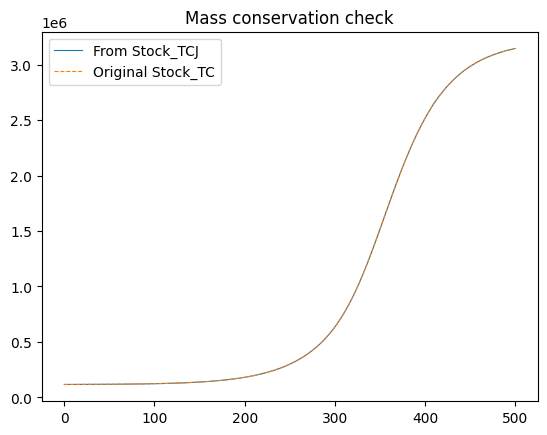

In [8]:
Stock_T = Stock_TCJ.sum(dim=["cohort", "type"]).to_pandas()
Stock_TC_check = Stock_TC.sum(axis=1)

plt.plot(Stock_T, label="From Stock_TCJ", linewidth=0.8)
plt.plot(Stock_TC_check, label="Original Stock_TC", linewidth=0.8, linestyle="--")
plt.legend()
plt.title("Mass conservation check")
plt.grid(False)
plt.show()

In [9]:
Type_split.head()

,Year,Parcelhus,Rekkehus,Etagehus,Stuehus
0,1600,0.0,0.0,0.0,1.0
1,1601,0.0,0.0,0.0,1.0
2,1602,0.0,0.0,0.0,1.0
3,1603,0.0,0.0,0.0,1.0
4,1604,0.0,0.0,0.0,1.0
